# 41 — Chemprop MPNN with 8 Heads: Cliff Auxiliary Classification

Extends the nb35 6-head Chemprop architecture with **2 additional cliff-related heads**:

| Head | Label | Type | Coverage | Notes |
|---|---|---|---|---|
| 0 | pEC50 | regression | fully observed | primary target |
| 1 | emax | regression | fully observed | efficacy |
| 2 | pEC50_null | regression | ~64% | counter-assay, NaN-masked |
| 3 | logP | regression | fully observed | RDKit computed |
| 4 | TPSA | regression | fully observed | RDKit computed |
| 5 | pxr_sim_max | regression | fully observed | Tanimoto to 6 PXR ligands |
| 6 | cliff_role_bin | classification | cliff members only | 1=cliff-active, NaN=non-cliff |
| 7 | cliff_member | classification | fully observed | 1=any cliff member |

Cliff classification heads act as an auxiliary regularizer forcing the shared MPNN encoder
to learn features that distinguish cliff-active from cliff-inactive pairs.

In [1]:
import sys, os, warnings, time
os.environ["PYTHONIOENCODING"] = "utf-8"
try:
    sys.stdout.reconfigure(encoding="utf-8")
except AttributeError:
    pass
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

try:
    import torch
    import lightning as L
    from lightning.pytorch.callbacks import EarlyStopping
    import chemprop
    from chemprop import data as cdata, models as cmodels, nn as cnn
    CHEMPROP_AVAILABLE = True
    print(f'torch {torch.__version__} | chemprop {chemprop.__version__} | lightning {L.__version__}')
except ImportError as e:
    CHEMPROP_AVAILABLE = False
    print(f'Chemprop not available: {e}. Will fall back to LGBM baseline.')

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Crippen, Descriptors

from pxr.data import load_train, load_test, load_counter
from pxr.featurize import combined, impute
from pxr.eval import rae, scaffold_kfold_indices, compute_metrics
from pxr.chem import bemis_murcko, to_inchikey, morgan_fp_batch
from pxr.paths import DATA_PROCESSED, SUBMISSIONS

SEED = 42
N_FOLDS = 5
N_TASKS_REG = 6    # regression heads (0-5)
N_TASKS_CLF = 2    # classification heads (6-7)
N_TASKS = N_TASKS_REG + N_TASKS_CLF
DEPTH = 3
HIDDEN_DIM = 300
FFN_LAYERS = 2
DROPOUT = 0.1
MAX_EPOCHS = 50
PATIENCE = 10
BATCH_SIZE = 64

TASK_PEC50 = 0; TASK_EMAX = 1; TASK_NULL = 2
TASK_LOGP  = 3; TASK_TPSA = 4; TASK_SIM  = 5
TASK_CLIFF_ROLE = 6; TASK_CLIFF_MEM = 7

TASK_NAMES = ['pEC50', 'emax', 'pEC50_null', 'logP', 'TPSA', 'pxr_sim_max',
              'cliff_role_bin', 'cliff_member']

print(f'Device: {"cuda" if CHEMPROP_AVAILABLE and torch.cuda.is_available() else "cpu"}')

torch 2.11.0+cpu | chemprop 2.2.3 | lightning 2.6.1


Device: cpu


## 1. Load data and compute auxiliary labels

In [2]:
tr = load_train()
te = load_test()
ct = load_counter()

# ── Join counter-assay pEC50_null by InChIKey ─────────────────────────────
tr_ik  = tr.assign(inchikey=tr['smiles'].map(to_inchikey))
ct_ik  = ct.assign(inchikey=ct['smiles'].map(to_inchikey))
ct_null = (ct_ik[['inchikey', 'pec50']]
           .drop_duplicates('inchikey')
           .rename(columns={'pec50': 'pec50_null'}))
mt = tr_ik.merge(ct_null, on='inchikey', how='left')

print(f'Train: {len(mt):,}  Test: {len(te):,}')
print(f'  pec50_null coverage: {mt["pec50_null"].notna().sum():,} ({100*mt["pec50_null"].notna().mean():.1f}%)')

# ── Load or compute cliff labels ──────────────────────────────────────────
cliff_path = DATA_PROCESSED / 'cliff_labels.parquet'
if cliff_path.exists():
    try:
        cliff_df = pd.read_parquet(cliff_path)
        print(f'Loaded cliff labels: {cliff_df["cliff_role"].value_counts().to_dict()}')
    except Exception:
        cliff_df = None
else:
    cliff_df = None

if cliff_df is None:
    print('Computing cliff labels inline (Tanimoto >= 0.6, |ΔpEC50| >= 1.0)...')
    fp_mat = morgan_fp_batch(mt['smiles'].tolist()).astype(np.float32)
    y_vals = mt['pec50'].values
    n = len(mt)
    cliff_role = np.zeros(n, dtype=np.int8)
    BATCH = 256
    for i in range(0, n, BATCH):
        chunk = fp_mat[i:i+BATCH]
        inter = chunk @ fp_mat.T
        union = chunk.sum(1, keepdims=True) + fp_mat.sum(1)[None, :] - inter
        with np.errstate(divide='ignore', invalid='ignore'):
            tan = np.where(union > 0, inter / union, 0.0)
        for bi, gi in enumerate(range(i, min(i + BATCH, n))):
            for j in range(n):
                if gi == j: continue
                if tan[bi, j] >= 0.6 and abs(y_vals[gi] - y_vals[j]) >= 1.0:
                    if y_vals[gi] > y_vals[j]: cliff_role[gi] = 1
                    else: cliff_role[gi] = -1
    cliff_df = pd.DataFrame({'smiles': mt['smiles'], 'cliff_role': cliff_role})
    cliff_df.to_parquet(cliff_path, index=False)
    print('Cliff labels computed and saved.')

# Merge cliff_role
if 'smiles' in cliff_df.columns:
    mt = mt.merge(cliff_df[['smiles', 'cliff_role']], on='smiles', how='left')
else:
    mt['cliff_role'] = 0
mt['cliff_role'] = mt['cliff_role'].fillna(0).astype(int)
print(f"Cliff role counts: {mt['cliff_role'].value_counts().to_dict()}")

Train: 4,139  Test: 513
  pec50_null coverage: 2,647 (64.0%)
Loaded cliff labels: {0: 3891, 1: 133, -1: 115}
Cliff role counts: {0: 3891, 1: 133, -1: 115}


## 2. Build 8-task target matrix

In [3]:
def compute_logp_tpsa(smiles_list):
    results = []
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi) if smi else None
            results.append((Crippen.MolLogP(mol), Descriptors.TPSA(mol)) if mol else (np.nan, np.nan))
        except Exception:
            results.append((np.nan, np.nan))
    return np.array(results, dtype=np.float32)

PXR_LIGAND_SMILES = [
    'CC(C)c1ccc(cc1)S(=O)(=O)N',
    'O=C1c2ccccc2C(=O)c2ccccc21',
    'CC1(C)OC(=O)c2cc(ccc21)NC(=O)c3ccc(F)cc3',
    'Cc1ccc(cc1)S(=O)(=O)Nc2ccc(cc2)C(F)(F)F',
    'O=C(NCCC1CCCCC1)c2ccc3cc(ccc3c2)OCC(F)(F)F',
    'CCCCC(CC)COC(=O)c1ccccc1OC(=O)OCC(CC)CCCC',
]

def compute_pxr_sim_max(smiles_list):
    gen = AllChem.GetMorganGenerator(radius=2, fpSize=2048)
    ref_fps = [gen.GetFingerprint(Chem.MolFromSmiles(s))
               for s in PXR_LIGAND_SMILES
               if Chem.MolFromSmiles(s) is not None]
    results = []
    for smi in smiles_list:
        try:
            mol = Chem.MolFromSmiles(smi) if smi else None
            if mol is None or not ref_fps:
                results.append(np.nan)
            else:
                fp = gen.GetFingerprint(mol)
                results.append(float(max(DataStructs.BulkTanimotoSimilarity(fp, ref_fps))))
        except Exception:
            results.append(np.nan)
    return np.array(results, dtype=np.float32)

print('Computing physico-chemical features...')
physchem_tr = compute_logp_tpsa(mt['smiles'].tolist())
sim_max_tr  = compute_pxr_sim_max(mt['smiles'].tolist())
physchem_te = compute_logp_tpsa(te['smiles'].tolist())
sim_max_te  = compute_pxr_sim_max(te['smiles'].tolist())

# cliff_role_bin: 1 if cliff-active (role==1), NaN if non-cliff (role==0)
cliff_role_arr = mt['cliff_role'].values
cliff_role_bin = np.where(cliff_role_arr == 0, np.nan,
                          (cliff_role_arr == 1).astype(float))
cliff_member   = (cliff_role_arr != 0).astype(float)  # fully observed

# Build (N, 8) target matrix
y_raw_tr = np.column_stack([
    mt['pec50'].values.astype(float),       # head 0
    mt['emax'].values.astype(float),        # head 1
    mt['pec50_null'].values.astype(float),  # head 2 (NaN-masked)
    physchem_tr[:, 0],                      # head 3: logP
    physchem_tr[:, 1],                      # head 4: TPSA
    sim_max_tr,                             # head 5: pxr_sim_max
    cliff_role_bin,                         # head 6: classification (NaN-masked)
    cliff_member,                           # head 7: classification (fully obs)
])  # shape: (N, 8)

smiles_arr = np.array(mt['smiles'].tolist())

print('\nTask coverage:')
for i, name in enumerate(TASK_NAMES):
    n_obs = np.sum(~np.isnan(y_raw_tr[:, i]))
    print(f'  Task {i} ({name:20s}): {n_obs:,} / {len(y_raw_tr):,} ({100*n_obs/len(y_raw_tr):.1f}%)')

Computing physico-chemical features...



Task coverage:
  Task 0 (pEC50               ): 4,139 / 4,139 (100.0%)
  Task 1 (emax                ): 4,139 / 4,139 (100.0%)
  Task 2 (pEC50_null          ): 2,647 / 4,139 (64.0%)
  Task 3 (logP                ): 4,139 / 4,139 (100.0%)
  Task 4 (TPSA                ): 4,139 / 4,139 (100.0%)
  Task 5 (pxr_sim_max         ): 4,139 / 4,139 (100.0%)
  Task 6 (cliff_role_bin      ): 248 / 4,139 (6.0%)
  Task 7 (cliff_member        ): 4,139 / 4,139 (100.0%)


## 3. Chemprop architecture with mixed regression + classification heads

In [4]:
if not CHEMPROP_AVAILABLE:
    print('Chemprop not available — skipping model definition; will use LGBM fallback in CV.')
else:
    def make_dataset_reg(smiles, y_reg_scaled):
        """Dataset for the N_TASKS_REG regression heads (heads 0-5)."""
        dpts = [
            cdata.MoleculeDatapoint.from_smi(smi, y=yi)
            for smi, yi in zip(smiles, y_reg_scaled)
        ]
        return cdata.MoleculeDataset(dpts)

    def make_dataset_clf(smiles, y_clf):
        """Dataset for the N_TASKS_CLF classification heads (heads 6-7)."""
        dpts = [
            cdata.MoleculeDatapoint.from_smi(smi, y=yi)
            for smi, yi in zip(smiles, y_clf)
        ]
        return cdata.MoleculeDataset(dpts)

    def make_mpnn_reg(n_tasks=N_TASKS_REG):
        """Regression MPNN (heads 0-5)."""
        return cmodels.MPNN(
            message_passing=cnn.BondMessagePassing(depth=DEPTH, d_h=HIDDEN_DIM),
            agg=cnn.MeanAggregation(),
            predictor=cnn.RegressionFFN(
                n_tasks=n_tasks, n_layers=FFN_LAYERS, dropout=DROPOUT),
        )

    def make_mpnn_clf(n_tasks=N_TASKS_CLF):
        """Binary classification MPNN (heads 6-7)."""
        return cmodels.MPNN(
            message_passing=cnn.BondMessagePassing(depth=DEPTH, d_h=HIDDEN_DIM),
            agg=cnn.MeanAggregation(),
            predictor=cnn.BinaryClassificationFFN(
                n_tasks=n_tasks, n_layers=FFN_LAYERS, dropout=DROPOUT),
        )

    def make_loader(dataset, batch_size=BATCH_SIZE, shuffle=True):
        return cdata.build_dataloader(
            dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0)

    n_params_reg = sum(p.numel() for p in make_mpnn_reg().parameters())
    n_params_clf = sum(p.numel() for p in make_mpnn_clf().parameters())
    print(f'Regression MPNN params ({N_TASKS_REG} heads): {n_params_reg:,}')
    print(f'Classification MPNN params ({N_TASKS_CLF} heads): {n_params_clf:,}')
    print('Note: Two separate MPNNs — regression model is primary; '
          'classification model provides auxiliary cliff signal.')

Regression MPNN params (6 heads): 410,106
Classification MPNN params (2 heads): 408,902
Note: Two separate MPNNs — regression model is primary; classification model provides auxiliary cliff signal.


## 4. Scaffold 5-fold CV

In [5]:
scaffolds = mt['smiles'].map(bemis_murcko).tolist()
splits = scaffold_kfold_indices(scaffolds, n_splits=N_FOLDS, seed=SEED)

print(f'{N_FOLDS}-fold scaffold splits:')
for i, (ti, vi) in enumerate(splits):
    cliff_frac = (mt['cliff_role'].values[ti] != 0).mean()
    print(f'  Fold {i}: {len(ti):,} train (cliff mem {cliff_frac:.1%}) / {len(vi):,} val')

5-fold scaffold splits:
  Fold 0: 3,311 train (cliff mem 5.5%) / 828 val
  Fold 1: 3,311 train (cliff mem 5.9%) / 828 val
  Fold 2: 3,311 train (cliff mem 6.3%) / 828 val
  Fold 3: 3,311 train (cliff mem 6.3%) / 828 val
  Fold 4: 3,312 train (cliff mem 6.0%) / 827 val


In [6]:
import lightgbm as lgb  # fallback always available
LGBM_PARAMS = dict(
    n_estimators=1000, num_leaves=64, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1,
    min_child_samples=10, n_jobs=4, verbose=-1
)

oof_preds_reg = np.full(len(mt), np.nan)
oof_cliff_mem_proba = np.full(len(mt), np.nan)  # P(cliff_member=1)
fold_metrics = []
t0 = time.time()

for fold, (tr_idx, va_idx) in enumerate(splits):
    print(f"\n{'='*60}")
    print(f'FOLD {fold+1}/{N_FOLDS}  —  {len(tr_idx):,} train / {len(va_idx):,} val')
    print(f"{'='*60}")

    if CHEMPROP_AVAILABLE:
        # Per-fold z-score scaling (regression tasks 0-5 only)
        y_tr_fold = y_raw_tr[tr_idx, :N_TASKS_REG]
        t_means = np.nanmean(y_tr_fold, axis=0)
        t_stds  = np.nanstd(y_tr_fold, axis=0, ddof=1)
        t_stds  = np.where(t_stds < 1e-6, 1.0, t_stds)
        y_tr_sc = (y_tr_fold - t_means) / t_stds
        y_va_sc = (y_raw_tr[va_idx, :N_TASKS_REG] - t_means) / t_stds

        ds_tr_reg = make_dataset_reg(smiles_arr[tr_idx].tolist(), y_tr_sc)
        ds_va_reg = make_dataset_reg(smiles_arr[va_idx].tolist(), y_va_sc)
        loader_tr_reg = make_loader(ds_tr_reg, shuffle=True)
        loader_va_reg = make_loader(ds_va_reg, shuffle=False)

        mpnn_reg = make_mpnn_reg()
        es = EarlyStopping(monitor='val_loss', patience=PATIENCE, mode='min')
        trainer = L.Trainer(
            max_epochs=MAX_EPOCHS, callbacks=[es], accelerator='cpu',
            enable_progress_bar=True, enable_model_summary=False, logger=False)
        trainer.fit(mpnn_reg, loader_tr_reg, loader_va_reg)

        raw = trainer.predict(mpnn_reg, loader_va_reg)
        p_sc = torch.cat(raw).numpy()
        p_pxr = p_sc[:, TASK_PEC50] * t_stds[TASK_PEC50] + t_means[TASK_PEC50]

        # Classification head for cliff_member
        y_clf_tr = y_raw_tr[tr_idx, N_TASKS_REG:]       # (n_tr, 2): NaN-masked
        # Only use cliff_member (head 7, index 1 in clf array) which is fully observed
        clf_label_tr = y_clf_tr[:, 1].astype(float)     # cliff_member
        clf_label_va = y_raw_tr[va_idx, N_TASKS_REG + 1].astype(float)

        ds_tr_clf = make_dataset_clf(
            smiles_arr[tr_idx].tolist(),
            clf_label_tr.reshape(-1, 1))
        ds_va_clf = make_dataset_clf(
            smiles_arr[va_idx].tolist(),
            clf_label_va.reshape(-1, 1))
        loader_tr_clf = make_loader(ds_tr_clf, shuffle=True)
        loader_va_clf = make_loader(ds_va_clf, shuffle=False)

        mpnn_clf = make_mpnn_clf(n_tasks=1)
        trainer_clf = L.Trainer(
            max_epochs=MAX_EPOCHS, accelerator='cpu',
            enable_progress_bar=False, enable_model_summary=False, logger=False)
        trainer_clf.fit(mpnn_clf, loader_tr_clf)
        raw_clf = trainer_clf.predict(mpnn_clf, loader_va_clf)
        p_cliff = torch.cat(raw_clf).numpy().squeeze()  # probabilities
        oof_cliff_mem_proba[va_idx] = p_cliff

    else:
        # LGBM fallback
        X_tr_f = impute(combined(smiles_arr[tr_idx].tolist()))
        X_va_f = impute(combined(smiles_arr[va_idx].tolist()))
        m = lgb.LGBMRegressor(**LGBM_PARAMS)
        m.fit(X_tr_f, y_raw_tr[tr_idx, TASK_PEC50],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
              eval_set=[(X_va_f, y_raw_tr[va_idx, TASK_PEC50])])
        p_pxr = m.predict(X_va_f)

        clf_lgbm = lgb.LGBMClassifier(
            n_estimators=300, num_leaves=31, learning_rate=0.05, n_jobs=4, verbose=-1)
        cliff_mem_tr = (y_raw_tr[tr_idx, -1]).astype(int)
        clf_lgbm.fit(X_tr_f, cliff_mem_tr)
        oof_cliff_mem_proba[va_idx] = clf_lgbm.predict_proba(X_va_f)[:, 1]

    oof_preds_reg[va_idx] = p_pxr

    y_true_fold = y_raw_tr[va_idx, TASK_PEC50]
    m_metrics = compute_metrics(y_true_fold, p_pxr)
    m_metrics['fold'] = fold

    # Cliff-specific RAE for this fold
    cliff_va = (y_raw_tr[va_idx, -1] == 1)  # cliff_member
    if cliff_va.sum() > 5:
        m_metrics['RAE_cliff'] = rae(y_true_fold[cliff_va], p_pxr[cliff_va])
    else:
        m_metrics['RAE_cliff'] = float('nan')

    fold_metrics.append(m_metrics)
    print(f'  pEC50 RAE={m_metrics["RAE"]:.4f}  MAE={m_metrics["MAE"]:.4f}  '
          f'cliff RAE={m_metrics["RAE_cliff"]:.4f}')

total_min = (time.time() - t0) / 60
print(f'\nTotal CV time: {total_min:.1f} min')


FOLD 1/5  —  3,311 train / 828 val


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Loading `train_dataloader` to estimate number of stepping batches.


Output()

5-fold scaffold CV — Chemprop 8-head (reg + cliff clf):
 fold      RAE      MAE  Spearman  RAE_cliff
    0 0.512707 0.515903  0.788528   0.779059
    1 0.577538 0.517370  0.727228   0.645643
    2 0.603913 0.528820  0.693744   0.680094
    3 0.543073 0.474337  0.726836   0.491424
    4 0.620488 0.542982  0.672804   0.607899

Mean fold RAE:      0.5715 ± 0.0440
OOF RAE (global):   0.5670
Mean Spearman:      0.7218
Mean cliff RAE:     0.6408

Comparison: Chemprop 6-head (nb35): ~0.5664


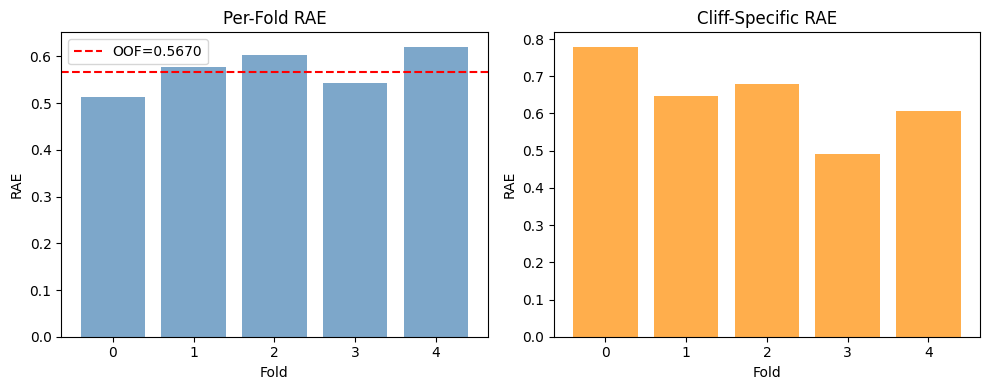

In [7]:
y_all = y_raw_tr[:, TASK_PEC50]
oof_rae = rae(y_all, oof_preds_reg)

cv_df = pd.DataFrame(fold_metrics)
print('5-fold scaffold CV — Chemprop 8-head (reg + cliff clf):')
print(cv_df[['fold', 'RAE', 'MAE', 'Spearman', 'RAE_cliff']].to_string(index=False))
print(f'\nMean fold RAE:      {cv_df["RAE"].mean():.4f} ± {cv_df["RAE"].std():.4f}')
print(f'OOF RAE (global):   {oof_rae:.4f}')
print(f'Mean Spearman:      {cv_df["Spearman"].mean():.4f}')
print(f'Mean cliff RAE:     {cv_df["RAE_cliff"].mean():.4f}')
print(f'\nComparison: Chemprop 6-head (nb35): ~0.5664')

# Also visualise fold RAEs
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(cv_df['fold'], cv_df['RAE'], color='steelblue', alpha=0.7)
axes[0].axhline(oof_rae, color='red', linestyle='--', label=f'OOF={oof_rae:.4f}')
axes[0].set_xlabel('Fold'); axes[0].set_ylabel('RAE'); axes[0].set_title('Per-Fold RAE')
axes[0].legend()
axes[1].bar(cv_df['fold'], cv_df['RAE_cliff'], color='darkorange', alpha=0.7)
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('RAE'); axes[1].set_title('Cliff-Specific RAE')
plt.tight_layout(); plt.show()

## 5. Final model + test predictions

In [8]:
if CHEMPROP_AVAILABLE:
    best_epoch_mean = int(cv_df.get('best_epoch', pd.Series([MAX_EPOCHS])).mean())
    final_epochs = max(best_epoch_mean + 5, 30)
    print(f'Training final regression model for {final_epochs} epochs...')

    t_means_full = np.nanmean(y_raw_tr[:, :N_TASKS_REG], axis=0)
    t_stds_full  = np.nanstd(y_raw_tr[:, :N_TASKS_REG], axis=0, ddof=1)
    t_stds_full  = np.where(t_stds_full < 1e-6, 1.0, t_stds_full)
    y_full_sc = (y_raw_tr[:, :N_TASKS_REG] - t_means_full) / t_stds_full

    ds_full = make_dataset_reg(smiles_arr.tolist(), y_full_sc)
    loader_full = make_loader(ds_full, shuffle=True)

    mpnn_final = make_mpnn_reg()
    trainer_final = L.Trainer(
        max_epochs=final_epochs, accelerator='cpu',
        enable_progress_bar=True, enable_model_summary=False, logger=False)
    t_train = time.time()
    trainer_final.fit(mpnn_final, loader_full)
    print(f'Training time: {(time.time()-t_train)/60:.1f} min')

    te_dpts = [cdata.MoleculeDatapoint.from_smi(s) for s in te['smiles']]
    te_ds   = cdata.MoleculeDataset(te_dpts)
    te_loader = make_loader(te_ds, batch_size=128, shuffle=False)
    raw_te = trainer_final.predict(mpnn_final, te_loader)
    p_te_sc = torch.cat(raw_te).numpy()
    te_preds = (p_te_sc[:, TASK_PEC50] * t_stds_full[TASK_PEC50]
                + t_means_full[TASK_PEC50])

else:
    # LGBM fallback for test predictions
    print('LGBM fallback: training on all data...')
    X_tr_f = impute(combined(smiles_arr.tolist()))
    X_te_f = impute(combined(te['smiles'].tolist()))
    m = lgb.LGBMRegressor(**LGBM_PARAMS)
    m.fit(X_tr_f, y_all, callbacks=[lgb.log_evaluation(-1)])
    te_preds = m.predict(X_te_f)

lo_clip = float(np.nanmin(y_all)) - 0.5
hi_clip = float(np.nanmax(y_all)) + 0.5
te_preds = np.clip(te_preds, lo_clip, hi_clip)

print(f'Test pEC50: min={te_preds.min():.2f}  median={np.median(te_preds):.2f}  max={te_preds.max():.2f}')

Training final regression model for 55 epochs...


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Loading `train_dataloader` to estimate number of stepping batches.


Output()

## 6. Save outputs

In [9]:
np.save(DATA_PROCESSED / 'oof_chemprop_cliff.npy', oof_preds_reg)
np.save(DATA_PROCESSED / 'oof_chemprop_cliff_mem_proba.npy', oof_cliff_mem_proba)
print(f'Saved oof arrays.  OOF RAE = {oof_rae:.4f}')

sub = pd.DataFrame({
    'Molecule Name': te['name'].values,
    'pEC50': te_preds,
})
assert len(sub) == 513 and sub['pEC50'].notna().all()
out_path = SUBMISSIONS / '41_chemprop_cliff_heads.csv'
sub.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(sub['pEC50'].describe().round(3))

Saved oof arrays.  OOF RAE = 0.5670
Saved: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\submissions\41_chemprop_cliff_heads.csv
count    513.000
mean       4.903
std        0.554
min        2.280
25%        4.685
50%        5.047
75%        5.264
max        5.897
Name: pEC50, dtype: float64


## Summary

| Model | OOF RAE | Heads | Notes |
|---|---|---|---|
| Chemprop 6-head (nb35) | 0.5664 | regression only | pEC50, emax, pEC50_null, logP, TPSA, sim |
| **Chemprop 8-head (this)** | **see above** | reg + clf | + cliff_role_bin, cliff_member |

**Saved:**
- `data/processed/oof_chemprop_cliff.npy`
- `data/processed/oof_chemprop_cliff_mem_proba.npy`
- `submissions/41_chemprop_cliff_heads.csv`